# **Programa Especializado en Credit Scoring con Python**
<img src="../../figuras/logo.png" width="200"/>

## 📊 **Sesión 8: Implementación del Score y Uso en la Toma de Decisiones.**

**Docente**: Enzo Infantes Zúñiga  
**Contacto**: <enzo.infantes28@gmail.com>  
**LinkedIn**: [enzo-infantes](https://www.linkedin.com/in/enzo-infantes/)

In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import sys
import os
import warnings
import joblib
import pickle

from sklearn.metrics import roc_auc_score, roc_curve, precision_recall_curve
warnings.filterwarnings("ignore")

np.random.seed(42)

absolute_path = os.path.dirname(os.path.dirname(os.getcwd()))
data_path = os.path.join(absolute_path, "data", "s08")
src_path_07 = os.path.join(absolute_path, "src", "s07")
src_path_08 = os.path.join(absolute_path, "src", "s08")
model_path = os.path.join(absolute_path, "models", "s08")
figure_path = os.path.join(absolute_path, "figuras", "s08")
sys.path.insert(0, src_path_07)
sys.path.insert(0, src_path_08)

from datetime import datetime
from preprocessing import Preprocessing
from feature_engineering import FeatureEngineering
from modeling import Modeling
from export_artefacts import export

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

## 🎯 **Objetivos de la sesión**

A modo de cierre de la parte 01: Desarrollo de Modelos de Credit Scoring, en la sesión de hoy abordaremos los siguientes puntos:
- **Construcción del Score a partir del Modelo**
- **Determinación del Punto de Corte**
- **Simulación de Decisión Crediticia**
    - Implementación Simulada con FastAPI

# **1. Preprocesamiento de Datos, Feature Engineering y Modeling**

In [23]:
df = pd.read_csv(os.path.join(data_path, "credit_data_v3.csv"))

In [24]:
df.columns

Index(['Customer_ID', 'Age', 'Income_INR', 'Employment_Years',
       'Marital_Status', 'Education_Level', 'Credit_History_Length',
       'Outstanding_Loans', 'Loan_Amount', 'Loan_Tenure_Months',
       'Savings_Account_Balance', 'Checking_Account_Balance',
       'No_of_Open_Accounts', 'No_of_Closed_Accounts', 'Total_Credit_Limit',
       'Total_Current_Balance', 'Credit_Utilization_Ratio',
       'No_of_Inquiries_6M', 'No_of_Inquiries_12M', 'DPD_30', 'DPD_60',
       'DPD_90', 'Worst_Current_Status',
       'Months_Since_Most_Recent_Delinquency', 'Max_Credit_Exposure',
       'Oldest_Trade_Open_Months', 'Newest_Trade_Open_Months', 'Default',
       'Application_Date'],
      dtype='object')

In [26]:
df.columns

Index(['age', 'income_inr', 'employment_years', 'marital_status',
       'education_level', 'credit_history_length', 'outstanding_loans',
       'loan_amount', 'loan_tenure_months', 'savings_account_balance',
       'checking_account_balance', 'no_of_open_accounts',
       'no_of_closed_accounts', 'total_credit_limit', 'total_current_balance',
       'credit_utilization_ratio', 'no_of_inquiries_6m', 'no_of_inquiries_12m',
       'max_credit_exposure', 'oldest_trade_open_months',
       'newest_trade_open_months', 'default', 'month', 'log_income_inr',
       'log_loan_amount', 'log_savings_account_balance',
       'log_checking_account_balance', 'log_total_credit_limit',
       'log_total_current_balance', 'log_max_credit_exposure'],
      dtype='object')

In [25]:
pp = Preprocessing(
    raw_data_dir    = data_path,
    output_data_dir = data_path,
    raw_filename    = 'credit_data_v3.csv',
)

df = pp.run_all()
pp.report()

[load]  2,000 rows × 29 cols loaded from 'c:\Users\einfantesz\Documents\Enzo\CreditScoring\CreditScoring\data\s08\credit_data_v3.csv'
[leak]  Dropped leakage columns: ['DPD_30', 'DPD_60', 'DPD_90', 'Worst_Current_Status', 'Months_Since_Most_Recent_Delinquency']
[create] Created 'month' column from 'Application_Date'.
[clean] Dropped non-feature cols: ['Customer_ID', 'Application_Date']
[dtype] Integer dtypes enforced.
[clean] Duplicates removed: 0 (remaining: 2,000)
[enc]   Education_Level → ordinal {HS:0, Grad:1, PG:2}
[enc]   Marital_Status  → ordinal {Single:0, Married:1, Divorced:2, Widowed:3}
[trf]   log1p applied → ['log_Income_INR', 'log_Loan_Amount', 'log_Savings_Account_Balance', 'log_Checking_Account_Balance', 'log_Total_Credit_Limit', 'log_Total_Current_Balance', 'log_Max_Credit_Exposure']
[clean] Column names standardised.

✅  Preprocessed data saved → 'c:\Users\einfantesz\Documents\Enzo\CreditScoring\CreditScoring\data\s08\preprocessed_credit_data.csv'
    Shape: 2,000 row

In [3]:
fe = FeatureEngineering(
    input_dir       = data_path,
    output_dir      = data_path,
    input_filename  = 'preprocessed_credit_data.csv',
)
train, test = fe.run_all()

fe.report_split()

[load]  2,000 rows × 30 cols loaded.
[feat]  Derived features created:
        debt_to_income, balance_to_income, savings_to_loan,
        monthly_installment_proxy, installment_to_income,
        inquiry_acceleration, utilization_per_open_account,
        total_accounts, closed_account_ratio,
        credit_hist_months, account_maturity, trade_gap
[split] OOT split  →  Train: 1,774 rows (28.52% default)  |  Test (OOT ≥ 2025-09): 226 rows (30.09% default)
[corr]  Dropped 9 highly correlated features (|r| > 0.9): ['oldest_trade_open_months', 'credit_hist_months', 'log_loan_amount', 'credit_history_length', 'max_credit_exposure', 'income_inr', 'employment_years', 'total_credit_limit', 'log_total_credit_limit']
[woe]   WoE encoding done. IV computed for 31 features.

── IV Summary ───────────────────────────────────────────────────
                     Feature     IV                      Strength
              log_income_inr 0.6116 Suspicious (possible leakage)
              debt_to_incom

[load]  Train: (1774, 26)  |  Test (OOT): (226, 26)
[load]  Features used (26): ['woe_age', 'woe_education_level', 'woe_loan_amount', 'woe_loan_tenure_months', 'woe_savings_account_balance', 'woe_checking_account_balance', 'woe_total_current_balance', 'woe_credit_utilization_ratio', 'woe_no_of_inquiries_6m', 'woe_no_of_inquiries_12m', 'woe_newest_trade_open_months', 'woe_log_income_inr', 'woe_log_savings_account_balance', 'woe_log_checking_account_balance', 'woe_log_total_current_balance', 'woe_log_max_credit_exposure', 'woe_debt_to_income', 'woe_balance_to_income', 'woe_savings_to_loan', 'woe_monthly_installment_proxy', 'woe_installment_to_income', 'woe_inquiry_acceleration', 'woe_utilization_per_open_account', 'woe_closed_account_ratio', 'woe_account_maturity', 'woe_trade_gap']
[load]  Train default rate: 28.52%  |  Test default rate: 30.09%

[train] Running RandomizedSearchCV (Logistic Regression)...
[train] Best params    : {'model__solver': 'liblinear', 'model__penalty': 'l1', 'mo

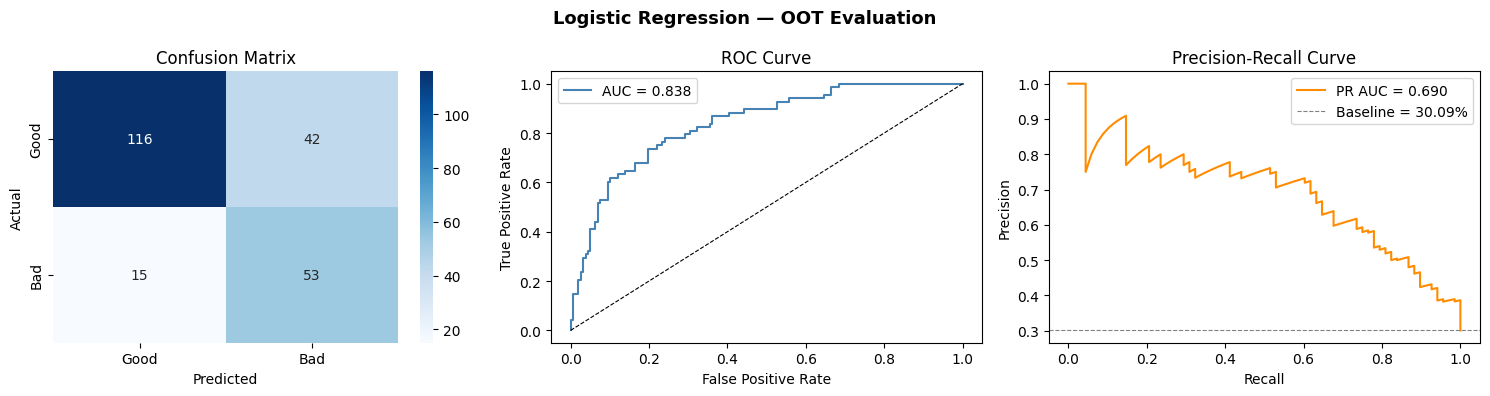

[plot]  Saved → 'c:\Users\einfantesz\Documents\Enzo\CreditScoring\CreditScoring\figuras\s08\lr_evaluation.png'


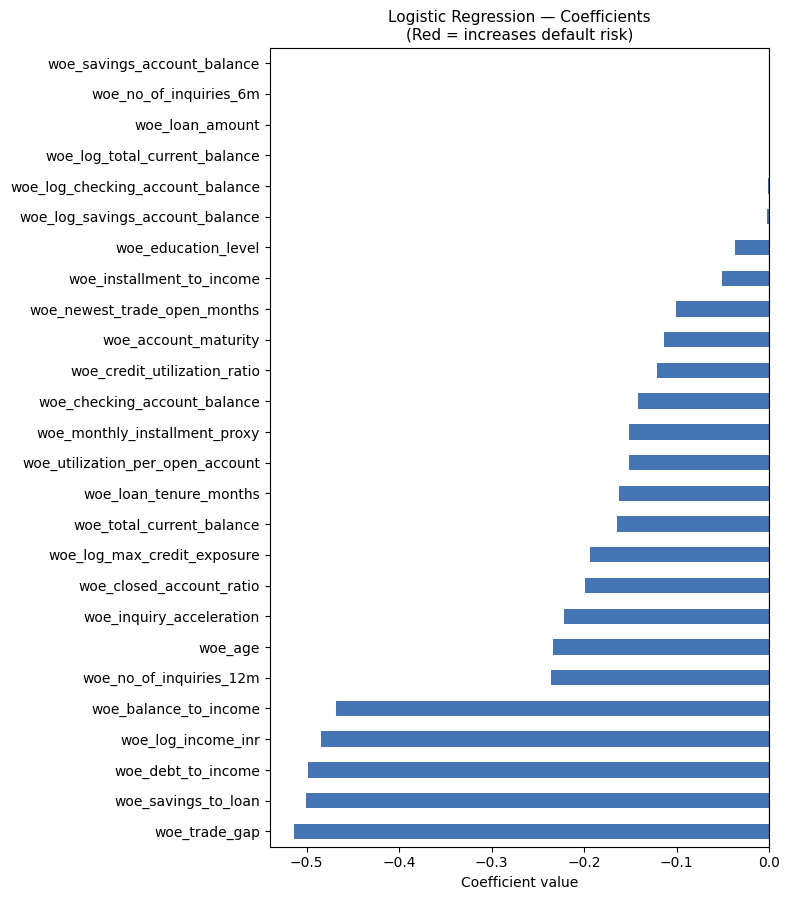

[plot]  Saved → 'c:\Users\einfantesz\Documents\Enzo\CreditScoring\CreditScoring\figuras\s08\lr_coefficients.png'
[save]  Predictions saved → 'c:\Users\einfantesz\Documents\Enzo\CreditScoring\CreditScoring\data\s08\test_predictions.csv'

✅  Modelling pipeline complete.


In [4]:
mdl = Modeling(
    train_path = os.path.join(data_path, 'train_fe.csv'),
    test_path  = os.path.join(data_path, 'test_fe.csv'),
    output_dir = data_path,
    figure_dir = figure_path,
)

mdl.run_all()

In [5]:
joblib.dump(mdl.best_model, os.path.join(model_path, 'logistic_regression_v2.pkl'))
print('Modelo guardado ✅')

best_model = joblib.load(os.path.join(model_path, 'logistic_regression_v2.pkl'))

Modelo guardado ✅


# **2. Validación del Modelo y Estabilidad**

In [6]:
TARGET = 'default'

features = mdl.features
train['score'] = mdl.best_model.predict_proba(train[features])[:, 1]
test['score']  = mdl.best_model.predict_proba(test[features])[:, 1]

train['month'] = train['month'].astype(str)
test['month']  = test['month'].astype(str)

OOT_START = test['month'].min()

print(f'Train: {len(train):,} obs | {train["month"].min()} → {train["month"].max()}')
print(f'Test:  {len(test):,}  obs | {test["month"].min()}  → {test["month"].max()}')
print(f'Default rate — Train: {train[TARGET].mean():.2%} | Test: {test[TARGET].mean():.2%}')

Train: 1,774 obs | 2023-01 → 2025-08
Test:  226  obs | 2025-09  → 2025-12
Default rate — Train: 28.52% | Test: 30.09%


## **2.1 Evolución del Gini / AUC en el Tiempo**

**Poder discriminatorio**:

$$\text{Gini} = 2 \times \text{AUC} - 1$$


In [7]:
gini_records = []
for label, df in [('Train', train), ('OOT Test', test)]:
    for month, grp in df.groupby('month'):
        auc_val  = roc_auc_score(grp[TARGET], grp['score'])
        fpr, tpr, _ = roc_curve(grp[TARGET], grp['score'])
        gini_records.append({
            'month'   : month,
            'set'     : label,
            'Gini'    : round(2 * auc_val - 1, 4),
            'KS'      : round(float(np.max(tpr - fpr)), 4),
            'n'       : len(grp),
            'bad_rate': round(grp[TARGET].mean(), 4)
        })

gini_df = pd.DataFrame(gini_records).sort_values('month').reset_index(drop=True)
print(gini_df)

      month       set    Gini      KS   n  bad_rate
0   2023-01     Train  0.8672  0.7856  48    0.3542
1   2023-02     Train  0.5783  0.4729  40    0.3250
2   2023-03     Train  0.7929  0.7390  62    0.2419
3   2023-04     Train  0.7643  0.6574  58    0.2586
4   2023-05     Train  0.6635  0.5714  57    0.2632
5   2023-06     Train  0.7121  0.6773  53    0.3774
6   2023-07     Train  0.7412  0.6150  72    0.2361
7   2023-08     Train  0.4931  0.5005  64    0.3594
8   2023-09     Train  0.6883  0.5974  58    0.2414
9   2023-10     Train  0.8039  0.6529  49    0.3061
10  2023-11     Train  0.6421  0.6171  59    0.3220
11  2023-12     Train  0.4935  0.5043  53    0.2075
12  2024-01     Train  0.6410  0.5797  62    0.3710
13  2024-02     Train  0.6217  0.6596  56    0.1607
14  2024-03     Train  0.5043  0.4718  54    0.2778
15  2024-04     Train  0.8600  0.8167  55    0.2727
16  2024-05     Train  0.7237  0.6645  54    0.2963
17  2024-06     Train  0.5530  0.5985  56    0.2143
18  2024-07 

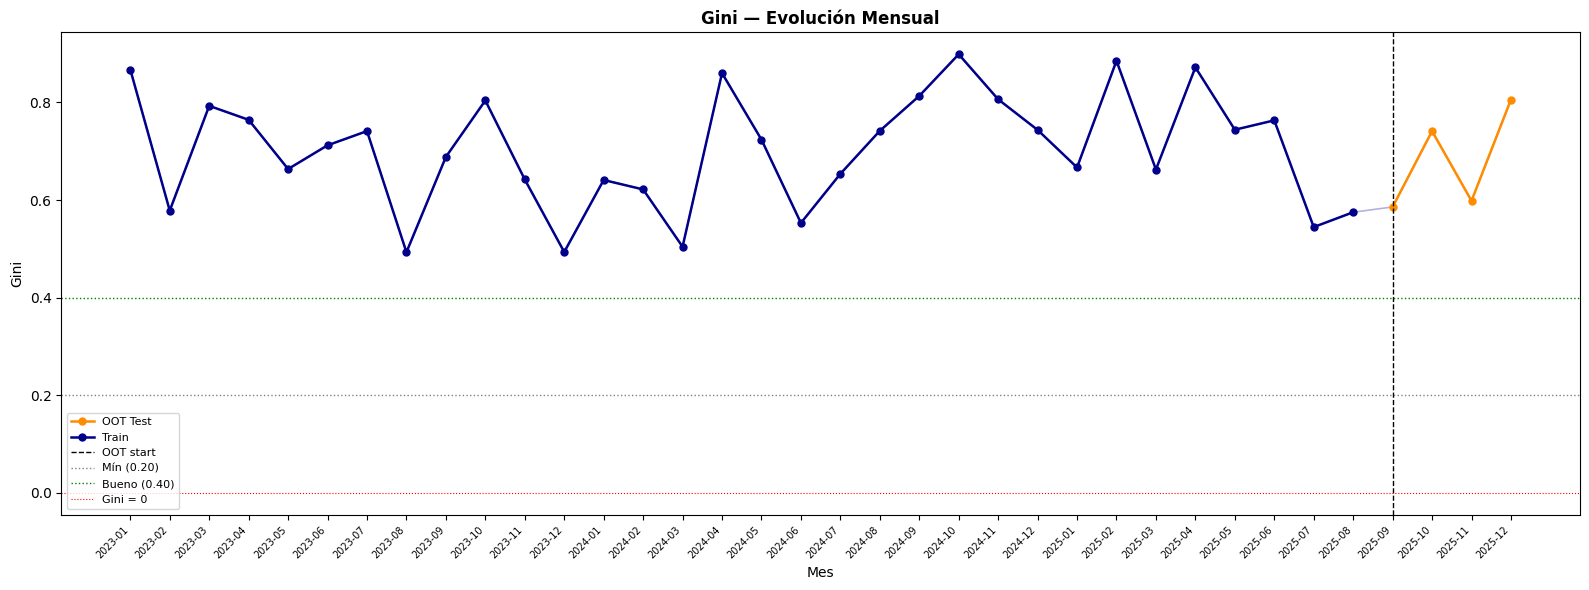

In [8]:
all_months = gini_df['month'].unique().tolist()
month_to_x = {m: i for i, m in enumerate(all_months)}

fig, ax = plt.subplots(figsize=(16, 6))
palette = {'Train': 'darkblue', 'OOT Test': 'darkorange'}

# Línea continua uniendo train + OOT
ax.plot(gini_df['month'].map(month_to_x), gini_df['Gini'],
        color='darkblue', linewidth=1.2, alpha=0.3, zorder=1)

# Puntos por set con color
for label, grp in gini_df.groupby('set'):
    xs = grp['month'].map(month_to_x)
    ax.plot(xs, grp['Gini'], marker='o', markersize=5,
            linewidth=1.8, label=label, color=palette[label], zorder=2)

ax.axvline(month_to_x['2025-09'], color='black', linestyle='--', linewidth=1, label='OOT start')
ax.axhline(0.20, color='grey',  linestyle=':', linewidth=1, label='Mín (0.20)')
ax.axhline(0.40, color='green', linestyle=':', linewidth=1, label='Bueno (0.40)')
ax.axhline(0.00, color='red',   linestyle=':', linewidth=0.8, label='Gini = 0')

ax.set_xticks(range(len(all_months)))
ax.set_xticklabels(all_months, rotation=45, ha='right', fontsize=7)
ax.set_title('Gini — Evolución Mensual', fontweight='bold')
ax.set_xlabel('Mes')
ax.set_ylabel('Gini')
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

## **2.2 Distribución del Score: Goods vs Bads**

Si las distribuciones de Good y Bad se superponen mucho, el modelo tiene poco poder discriminatorio.

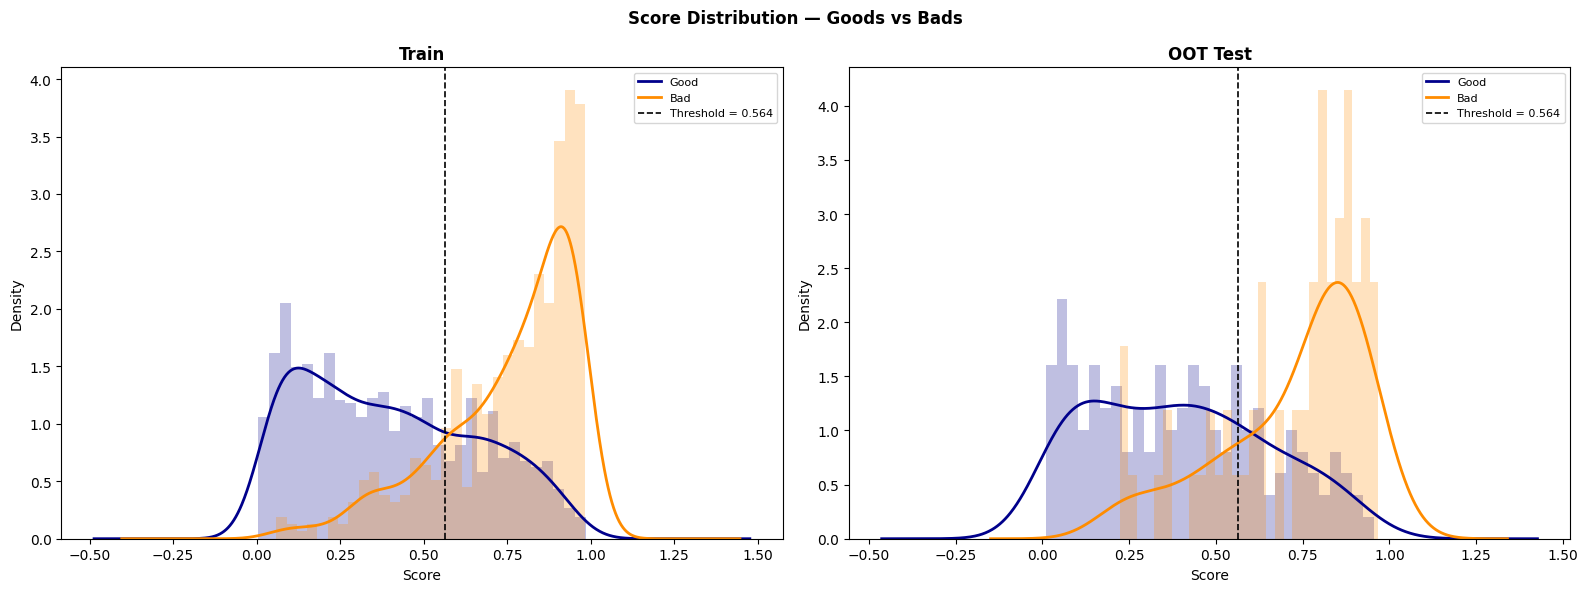

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, (label, df) in zip(axes, [('Train', train), ('OOT Test', test)]):
    for cls, color, name in [(0, 'darkblue', 'Good'), (1, 'darkorange', 'Bad')]:
        subset = df[df[TARGET] == cls]['score']
        subset.plot.kde(ax=ax, color=color, linewidth=2, label=name)
        ax.hist(subset, bins=30, alpha=0.25, color=color, density=True)
    ax.axvline(mdl.threshold, color='black', linestyle='--', linewidth=1.2, label=f'Threshold = {mdl.threshold:.3f}')
    ax.set_title(f'{label}', fontweight='bold')
    ax.set_xlabel('Score')
    ax.legend(fontsize=8)

fig.suptitle('Score Distribution — Goods vs Bads', fontweight='bold')
plt.tight_layout()
plt.show()

# **3. Construcción del Score a partir del Modelo** 

En un modelo de **Credit Scoring**, la **Regresión Logística** produce una probabilidad de incumplimiento (PD):

$$
E(Y \mid X) = P(Y = 1 \mid X) = PD
$$

Sin embargo, en la industria financiera las decisiones no se toman directamente con probabilidades, sino con un score crediticio, que es una transformación monotónica del modelo logístico. La relación entre el modelo logístico y el score se basa en los **odds** (Bad : Good):

$$
Odds = \frac{P(Y=1)}{P(Y=0)} = \frac{p_i}{1 - p_i} = e^{X_i\beta}
$$

**Odds** de 1:50 → por cada 51 clientes, 50 pagan y 1 no. Cuanto más bajo las odds, mejor el cliente. 

Para construir nuestro score usaremos la **inversa del Odds Ratio (Good: Bad)**. Luego se utiliza una transformación lineal para obtener el *Final Scorecard Production*:
$$
Score = Offset + Factor⋅ln(Odds_{Good:Bad})  
$$

Idea: Mayor PD → mayor riesgo → Menor Odds ratio → menor Score.

Donde los parámetros del score se definen mediante tres valores estándar:
- Score base (Score0): Fija el punto central de la escala (ej. 600)
- Odds base (Odds0): Odds asociadas al Score₀ 
- PDO (Points to Double the Odds): Cuántos puntos deben cambiar para duplicar el riesgo (ej. 20 o 30).

**Cálculo de Factor y Offset**
- Factor: Determina qué tan “sensible” es la escala
$$
Factor = \frac{PDO}{ln(2)}
$$

- Offset: Ajusta la escala para que el punto base coincida con Score₀.
$$
Offset = Score0 - Factor * Ln(Odds0)
$$

Por lo tanto, se puede calcular el score final:
$$
Score = Offset + Factor \cdot \ln\left( \frac{1 - PD}{PD} \right)
$$





Flujo Completo del Credit Scoring:
```
Datos del cliente
      ↓
Feature Engineering
      ↓
Transformación WOE
      ↓
Modelo Logístico
      ↓
Probabilidad de Default (PD)
      ↓
Transformación a Score
      ↓
Cutoff de Decisión
      ↓
Aprobación / Rechazo
      ↓
Implementación vía API
```

In [10]:
# ---------------------------
# 1) PARÁMETROS DE ESCALA (negocio)
# ---------------------------

PDO   = 20      # Sensibilidad: cada 20 puntos las odds (Good:Bad) se duplican.
Score0 = 600    # Score base: el "punto de referencia" de tu escala (comunicación/continuidad).
Odds0  = (1 - 0.29) / 0.29  # ≈ 2.45     # Odds0 (Good:Bad) asociadas a Score0. 
                                         # Esto equivale a Good:Bad ≈ 2.45 : 1, es decir: por cada 3.45 cliente 2.45 son Buenos 1 es Malo (~29% PD).
                                         # Quiero que Score0 = 600 represente un cliente promedio (29% de PD)

# ---------------------------
# 2) FACTOR y OFFSET (derivados de la escala)
# ---------------------------
factor = PDO / np.log(2)  # Factor convierte cambios en ln(odds) a puntos respetando el PDO.
offset = Score0 - factor * np.log(Odds0) # Dónde quieres que caiga el score base (Score0)
print(f"Factor: {factor:.2f}, Offset: {offset:.2f}")

# ---------------------------
# 3) PROBABILIDADES DEL MODELO
# ---------------------------
pds = mdl.best_model.predict_proba(train[features])[:,1]  # PD = P(Y=1 | X)

# ---------------------------
# 4) TRANSFORMACIÓN PD -> SCORE (convención Good:Bad)
# ---------------------------
odds = (1 - pds) / pds              # Good:Bad. Cuanto mayor, mejor cliente.
score = offset + factor * np.log(odds)
# Con esta forma, si PD sube -> odds bajan -> ln(odds) baja -> score baja (monotonía correcta).

# ---------------------------
# 5) SALIDA TABULAR
# ---------------------------

df_score = pd.DataFrame({
    'scorecard': score,       # tu score final en puntos
    'odds': np.log(odds),        # ln(Good:Bad) para análisis interno (no es necesario reportar a negocio)
    'prob_default': pds,      # PD del modelo (ya clippeada)
    'target': train[TARGET]   # etiqueta real (0=Good, 1=Bad)
})

print(df_score.head())

Factor: 28.85, Offset: 574.16
    scorecard      odds  prob_default  target
0  591.105695  0.587131      0.357293       0
1  662.357869  3.056543      0.044936       0
2  573.545624 -0.021455      0.505363       0
3  583.254859  0.315042      0.421885       0
4  521.151045 -1.837313      0.862631       1


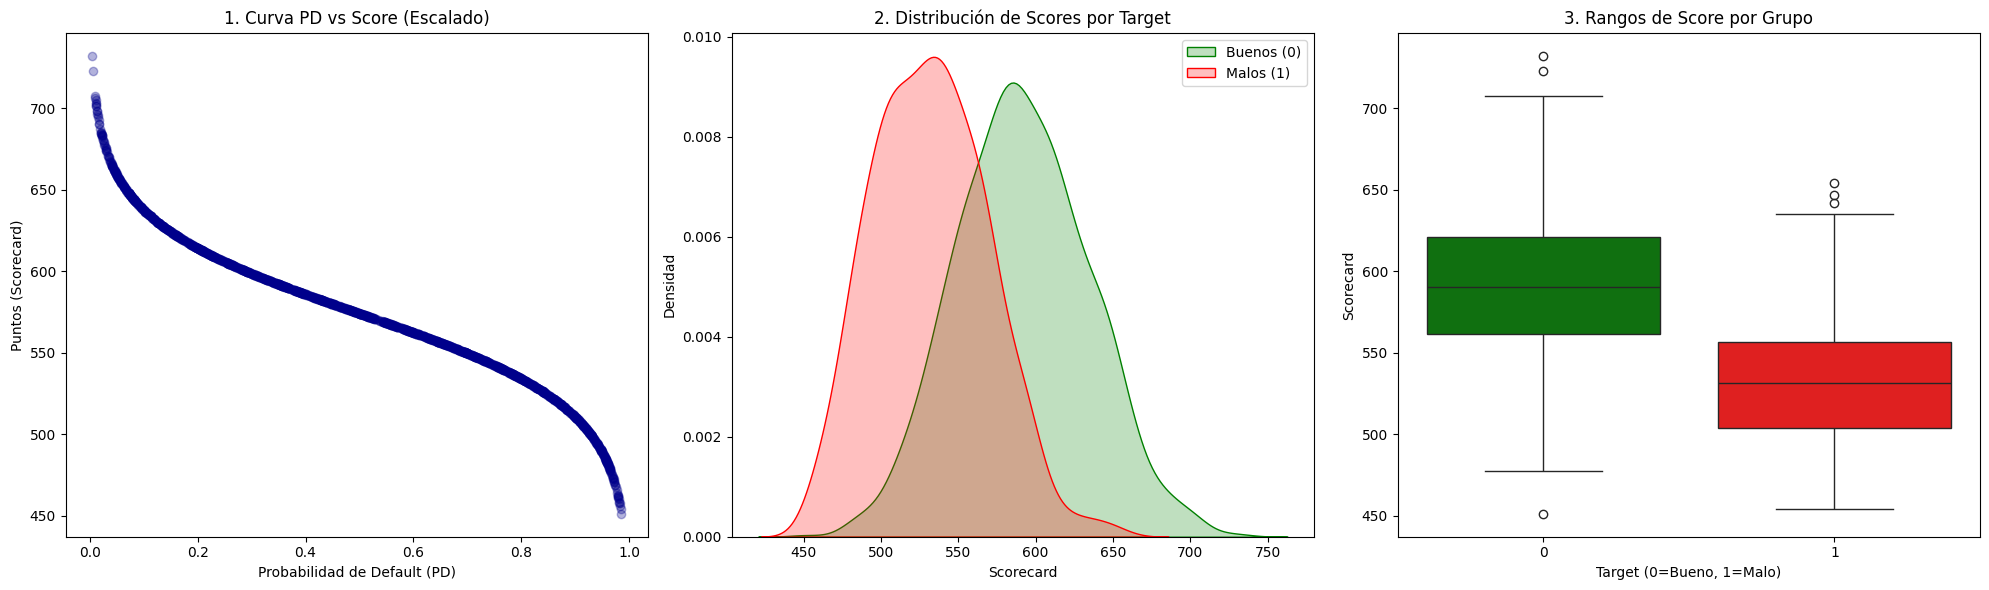

In [11]:
fig, ax = plt.subplots(1, 3, figsize=(20, 6))

# --- GRÁFICO 1: Relación Matemática (Validación de la escala) ---
ax[0].scatter(df_score['prob_default'], df_score['scorecard'], alpha=0.3, color='darkblue')
ax[0].set_title('1. Curva PD vs Score (Escalado)')
ax[0].set_xlabel('Probabilidad de Default (PD)')
ax[0].set_ylabel('Puntos (Scorecard)')
ax[0].grid(False)

# --- GRÁFICO 2: Distribución de Scores por Target (Discriminación) ---
# Este es el más importante para negocio: ¿Se separan los grupos?
sns.kdeplot(data=df_score[df_score['target'] == 0], x='scorecard', fill=True, label='Buenos (0)', ax=ax[1], color='green')
sns.kdeplot(data=df_score[df_score['target'] == 1], x='scorecard', fill=True, label='Malos (1)', ax=ax[1], color='red')
ax[1].set_title('2. Distribución de Scores por Target')
ax[1].set_xlabel('Scorecard')
ax[1].set_ylabel('Densidad')
ax[1].legend()

# --- GRÁFICO 3: Boxplot de Score (Outliers y Rangos) ---
sns.boxplot(data=df_score, x='target', y='scorecard', palette={'0': "green", '1': "red"}, ax=ax[2])
ax[2].set_title('3. Rangos de Score por Grupo')
ax[2].set_xlabel('Target (0=Bueno, 1=Malo)')
ax[2].set_ylabel('Scorecard')

plt.tight_layout()
plt.show()

# **4. Determinación del Punto de Corte**

```
Score bajo              Score alto
|----------------|----------------|
   Reject zone        Approve zone
```

## **4.1 KS (Kolmogorov–Smirnov)**

In [12]:
y_true = df_score["target"]
scores = df_score["scorecard"]

risk = -scores # Convertimos score a "riesgo" porque roc_curve asume que valores altos = mayor probabilidad de clase positiva

fpr, tpr, thresholds = roc_curve(y_true, risk)

ks = tpr - fpr
ks_idx = np.argmax(ks)

ks_value = ks[ks_idx]
cutoff_score = -thresholds[ks_idx]

approved = df_score[df_score["scorecard"] >= cutoff_score]
approval_rate = len(approved) / len(df_score)
default_rate = approved["target"].mean()

print("KS:", ks_value)
print("Cutoff óptimo:", cutoff_score)
print("Approval Rate:", round(approval_rate, 4))
print("Default Rate (portfolio):", round(default_rate, 4))

KS: 0.5481041383523896
Cutoff óptimo: 566.7437445548188
Approval Rate: 0.5603
Default Rate (portfolio): 0.0865


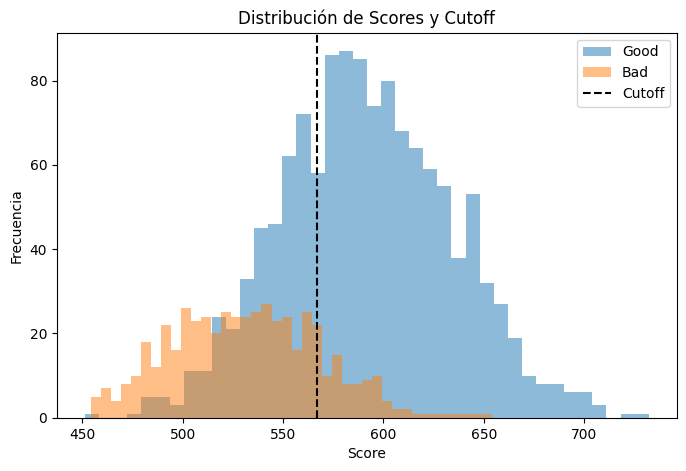

In [13]:
plt.figure(figsize=(8,5))

good = df_score[df_score.target==0]["scorecard"]
bad = df_score[df_score.target==1]["scorecard"]

plt.hist(good, bins=40, alpha=0.5, label="Good")
plt.hist(bad, bins=40, alpha=0.5, label="Bad")

plt.axvline(cutoff_score, color='black', linestyle='--', label="Cutoff")

plt.legend()
plt.title("Distribución de Scores y Cutoff")
plt.xlabel("Score")
plt.ylabel("Frecuencia")
plt.show()

## **4.2 Optimización basada en costos**

$$
Profit=(Good⋅Gain)−(Bad⋅Loss)
$$

In [14]:
# 1. Definimos las pérdidas y ganancias por cada estado de la naturaleza.
profit_matrix = {
    "TP": 100,
    "FP": -350,
    "FN": -50,
    "TN": 0
}

# 2. Probamos diferentes cutoffs del score
cutoffs = np.linspace(
    df_score['scorecard'].min(),
    df_score['scorecard'].max(),
    300
)

# 3. Calculamos el profit para cada cutoff y almacenamos los resultados
results = []

for c in cutoffs:

    approve = df_score['scorecard'] >= c

    TP = ((approve) & (df_score['target'] == 0)).sum()
    FP = ((approve) & (df_score['target'] == 1)).sum()
    FN = ((~approve) & (df_score['target'] == 0)).sum()
    TN = ((~approve) & (df_score['target'] == 1)).sum()

    profit = (
        TP * profit_matrix["TP"] +
        FP * profit_matrix["FP"] +
        FN * profit_matrix["FN"] +
        TN * profit_matrix["TN"]
    )

    results.append({
        "cutoff": c,
        "profit": profit,
        "approval_rate": approve.mean(),
        "default_rate": df_score.loc[approve, "target"].mean()
    })

profit_df = pd.DataFrame(results)
optimal_row = profit_df.loc[profit_df['profit'].idxmax()] # profit_df.loc[profit_df['profit'].idxmax()][0]

print(optimal_row)

cutoff             566.851168
profit           42900.000000
approval_rate        0.559188
default_rate         0.085685
Name: 123, dtype: float64


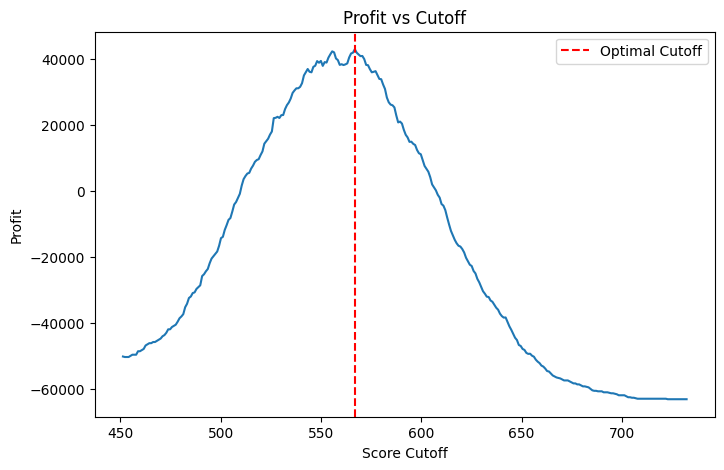

In [15]:
plt.figure(figsize=(8,5))

plt.plot(profit_df.cutoff, profit_df.profit)
plt.axvline(optimal_row.cutoff, color='red', linestyle='--', label='Optimal Cutoff')

plt.title("Profit vs Cutoff")
plt.xlabel("Score Cutoff")
plt.ylabel("Profit")

plt.legend()
plt.show()

# **5. Simulación de Decisión Crediticia**

```
JSON input
   ↓
preprocessing.py
   ↓
feature_engineering.py
   ↓
modelo.pkl
   ↓
predict_proba
   ↓
scorecard
   ↓
cutoff
   ↓
decision
```

Instalar dependencias: 
```
pip install fastapi uvicorn
```

In [16]:
export(
    model    = mdl.best_model,   # tu estimador sklearn entrenado
    fe       = fe,               # instancia FeatureEngineering post run_all()
    features = features,         # lista de columnas woe_* que entran al modelo
    cutoff   = cutoff_score,     # tu cutoff óptimo
)

✅  model.pkl       → C:\Users\einfantesz\Documents\Enzo\CreditScoring\CreditScoring\models\s08\api\model.pkl
✅  woe_maps.pkl    → C:\Users\einfantesz\Documents\Enzo\CreditScoring\CreditScoring\models\s08\api\woe_maps.pkl  (31 features)
✅  config.json     → C:\Users\einfantesz\Documents\Enzo\CreditScoring\CreditScoring\models\s08\api\config.json

   cutoff   = 566.7437
   features = 26  →  ['woe_age', 'woe_education_level', 'woe_loan_amount', 'woe_loan_tenure_months'] ...
   PDO=20.0 | Score0=600.0 | Odds0=2.4483

🎯  Listo. Copia la carpeta 'C:\Users\einfantesz\Documents\Enzo\CreditScoring\CreditScoring\models\s08\api/' junto a main.py y levanta la API.
